In [1]:


# ── CELL 1: Kaggle setup + download ──────────────────────────────
from google.colab import files
import os, zipfile

print("Upload your kaggle.json:")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

with zipfile.ZipFile("database-for-emotion-recognition-system-gameemo.zip", "r") as z:
    z.extractall(".")

print("Done! Folders:", [f for f in os.listdir(".") if os.path.isdir(f)])



Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Done! Folders: ['.config', 'GAMEEMO', 'sample_data']


In [3]:


# ── CELL 2: Install (restart runtime after this) ─────────────────
!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn scipy



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cu

In [27]:


# ── CELL 3: Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, NumberOfPoints, BettiCurve
from gtda.diagrams import Scaler as DiagramScaler
from gtda.curves import StandardFeatures


In [28]:

# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"
SFREQ    = 128   # EMOTIV EPOC sampling frequency

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())

# Frequency bands — each will get its own TDA pipeline
BANDS = {
    "delta": (0.5, 4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}

# Takens embedding params
TIME_DELAY = 2
DIMENSION  = 3

# SlidingWindow params
SW_SIZE   = 50    # ~390ms at 128Hz — enough for topology to form
SW_STRIDE = 25    # 50% overlap

HOMOLOGY_DIMS = (0, 1)
BETTI_BINS    = 10
RANDOM_STATE  = 42


In [29]:

# ── CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    """Returns per-emotion blocks as lists, NOT concatenated."""
    all_X, all_y = [], []
    csv_dir = os.path.join(
        DATA_DIR, f"(S{subject_id:02d})",
        "Preprocessed EEG Data", ".csv format"
    )
    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)
        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue
        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()
        data = df[cols].values.astype(np.float64)
        all_X.append(data)
        all_y.append(np.full(len(data), label, dtype=int))
    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")
    return all_X, all_y


In [30]:

# ── CELL 6: Bandpass filter ───────────────────────────────────────
def bandpass(signal, low, high, fs=SFREQ, order=4):
    """
    Filter a 1-D signal to a specific frequency band.
    Returns a cleaner oscillating signal whose Takens embedding
    reconstructs a proper geometric shape (ellipse/torus) in
    phase space, making persistent homology more meaningful.
    """
    nyq  = fs / 2.0
    low  = max(low, 0.1)           # avoid 0 Hz
    high = min(high, nyq - 0.1)    # avoid Nyquist
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)


In [31]:
# ── CELL 7: Persistence feature extractor (shared) ───────────────
def persistence_stats(X_pd):
    """Birth/Death/Lifetime mean+std per homology dim."""
    n_windows = X_pd.shape[0]
    all_rows  = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.extend([0.0] * 6)
            else:
                b = finite[:, 0]; d = finite[:, 1]; l = d - b
                row.extend([b.mean(), b.std(), d.mean(), d.std(), l.mean(), l.std()])
        all_rows.append(row)
    return np.array(all_rows)



In [32]:

def diagram_to_features(X_pd):
    """
    Extracts 28 scalar features from a batch of persistence diagrams:
      - 12: birth/death/lifetime stats (mean+std) per H0, H1
      - 2:  persistence entropy per H0, H1
      - 2:  amplitude (landscape norm) per H0, H1
      - 2:  number of points per H0, H1
      - 10: betti curve stats (mean/std/median/max/min) per H0, H1
    """
    feat_bdl = persistence_stats(X_pd)
    feat_pe  = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd)
    feat_amp = Amplitude(metric="landscape", order=None).fit_transform(X_pd)
    feat_np  = NumberOfPoints().fit_transform(X_pd)
    betti    = BettiCurve(n_bins=BETTI_BINS).fit_transform(X_pd)
    feat_bc  = StandardFeatures().fit_transform(betti)
    return np.hstack([feat_bdl, feat_pe, feat_amp, feat_np, feat_bc])  # (n_win, 28)

In [33]:

# ── CELL 8a: Per-band per-channel TDA ────────────────────────────
def tda_band_channel(signal_1d, labels, band_name):
    """
    1. Bandpass filter the 1-D signal to the given band
    2. SingleTakensEmbedding → reconstructs phase space attractor
       (clean oscillation gives proper ellipse/torus geometry)
    3. SlidingWindow → local point cloud snapshots
    4. VietorisRipsPersistence → persistence diagram per window
    5. diagram_to_features → 28 scalar features per window

    signal_1d : (T,)   one EEG channel, raw
    band_name : str    key into BANDS dict
    """
    low, high = BANDS[band_name]

    # Filter to this frequency band
    filtered = bandpass(signal_1d, low, high)

    # Takens embedding on the FILTERED signal
    # Clean oscillations → proper geometric shapes in phase space
    # → more meaningful persistent homology
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,
    )
    X_emb, y_emb = STE.fit_transform_resample(filtered, labels)

    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)

    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = DiagramScaler().fit_transform(VR.fit_transform(X_win))

    return diagram_to_features(X_pd), y_win



In [34]:

# ── CELL 8b: Multivariate cross-channel TDA ───────────────────────
def tda_multivariate(signal_14d, labels):
    """
    All 14 channels together → SlidingWindow → VR → 28 features.
    No filtering here — captures cross-channel spatial topology
    at the raw signal level.
    """
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(signal_14d, labels)

    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = DiagramScaler().fit_transform(VR.fit_transform(X_win))

    return diagram_to_features(X_pd), y_win


In [35]:

# ── CELL 9: Full feature extraction for one emotion block ─────────
def extract_block_features(X_block, y_block):
    """
    For one continuous emotion block (T, 14):
      - Run band TDA on each of 5 bands × 14 channels = 70 calls → 1960 feats
      - Run multivariate TDA once → 28 feats
      - Concatenate → 1988 features per window

    Returns X_feat (n_windows, 1988), y_win (n_windows,)
    """
    n_channels = X_block.shape[1]
    all_band_feats = []   # will hold 5*14 = 70 arrays of (n_win, 28)
    ref_y_win      = None
    min_wins       = None

    # ── Per-band per-channel features ──────────────────────────────
    for band_name in BANDS:
        for ch_idx in range(n_channels):
            try:
                feat, y_win = tda_band_channel(
                    X_block[:, ch_idx], y_block, band_name
                )
                all_band_feats.append(feat)
                if ref_y_win is None:
                    ref_y_win = y_win
                    min_wins  = feat.shape[0]
                else:
                    min_wins = min(min_wins, feat.shape[0])
            except Exception as e:
                # fill zeros if a band fails (e.g. too short signal)
                print(f"    [warn] {band_name}/ch{ch_idx}: {e}")
                all_band_feats.append(None)

    # Replace failed bands with zeros
    for i, f in enumerate(all_band_feats):
        if f is None:
            all_band_feats[i] = np.zeros((min_wins, 28))

    band_feats = np.hstack([f[:min_wins] for f in all_band_feats])  # (n_win, 1960)

    # ── Multivariate cross-channel features ───────────────────────
    multi_feat, multi_y = tda_multivariate(X_block, y_block)
    min_wins2 = min(min_wins, multi_feat.shape[0])

    X_feat = np.hstack([
        band_feats[:min_wins2],          # (n_win, 1960)
        multi_feat[:min_wins2],          # (n_win, 28)
    ])                                   # (n_win, 1988)

    y_win = ref_y_win[:min_wins2]
    return X_feat, y_win


In [36]:

# ── CELL 10: Extract features for all subjects ────────────────────
def extract_subject_features(subject_id):
    """
    Load 4 emotion blocks. Split each 80/20. Extract features
    on train and test portions separately (no leakage).
    """
    blocks_X, blocks_y = load_subject(subject_id)

    feat_tr_parts, y_tr_parts = [], []
    feat_te_parts, y_te_parts = [], []

    for emotion_idx, (X_block, y_block) in enumerate(zip(blocks_X, blocks_y)):
        game_tag = list(EMOTIONS.keys())[emotion_idx]
        emotion  = EMOTIONS[game_tag]
        print(f"  [{emotion}] extracting features ...", end=" ", flush=True)

        n = len(y_block)
        split_idx = int(n * 0.8)

        X_tr_b, y_tr_b = X_block[:split_idx], y_block[:split_idx]
        X_te_b, y_te_b = X_block[split_idx:], y_block[split_idx:]

        f_tr, yw_tr = extract_block_features(X_tr_b, y_tr_b)
        f_te, yw_te = extract_block_features(X_te_b, y_te_b)

        feat_tr_parts.append(f_tr)
        y_tr_parts.append(yw_tr)
        feat_te_parts.append(f_te)
        y_te_parts.append(yw_te)

        print(f"tr_wins={f_tr.shape[0]}, te_wins={f_te.shape[0]}, feats={f_tr.shape[1]}")

    X_tr = np.vstack(feat_tr_parts)
    y_tr = np.concatenate(y_tr_parts)
    X_te = np.vstack(feat_te_parts)
    y_te = np.concatenate(y_te_parts)

    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    return X_tr, y_tr, X_te, y_te


In [37]:
import torch.nn as nn

# ── CELL 11: MLP definition ───────────────────────────────────────
class TDA_MLP(nn.Module):
    def __init__(self, in_dim, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def train_subject_mlp(X_tr, y_tr, X_te, y_te, subject_id):
    # Scale + remove zero-variance features
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_te_sc  = scaler.transform(X_te)

    sel      = VarianceThreshold(threshold=0.01)
    X_tr_sc  = sel.fit_transform(X_tr_sc)
    X_te_sc  = sel.transform(X_te_sc)

    X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr,    dtype=torch.long)
    X_te_t = torch.tensor(X_te_sc, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=256, shuffle=True)

    device    = "cuda" if torch.cuda.is_available() else "cpu"
    model     = TDA_MLP(in_dim=X_tr_sc.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=5, factor=0.5)

    EPOCHS       = 100
    PATIENCE     = 10
    best_val_acc = 0.0
    best_weights = None
    patience_ctr = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()
        val_acc = accuracy_score(y_te, val_pred)
        scheduler.step(1 - val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break
        model.train()

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()

    acc = accuracy_score(y_te, y_pred)
    print(f"  S{subject_id:02d} — best_val_acc={best_val_acc:.4f}, test_acc={acc:.4f}")
    return acc, y_te, y_pred

In [38]:

# ── CELL 12: Confusion matrix plot ───────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


In [39]:

# ── CELL 13: Run all subjects ─────────────────────────────────────

subjects_to_run = range(1, 5)

all_X_tr, all_y_tr = [], []
all_X_te, all_y_te = [], []

for sid in subjects_to_run:
    print(f"\n{'='*55}\nSubject S{sid:02d}\n{'='*55}")
    try:
        X_tr, y_tr, X_te, y_te = extract_subject_features(sid)
        all_X_tr.append(X_tr); all_y_tr.append(y_tr)
        all_X_te.append(X_te); all_y_te.append(y_te)
        print(f"  → train={X_tr.shape}, test={X_te.shape}")
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")



Subject S01
  [Boring] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Calm] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Horror] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Funny] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  → train=(4888, 1420), test=(1216, 1420)

Subject S02
  [Boring] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Calm] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Horror] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Funny] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  → train=(4888, 1420), test=(1216, 1420)

Subject S03
  [Boring] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Calm] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Horror] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  [Funny] extracting features ... tr_wins=1222, te_wins=304, feats=1420
  → train=

In [40]:

# ── CELL 14: Per-subject MLP training ────────────────────────────
print("\nPer-subject MLP training...\n")

subject_results          = []
all_y_te_ps, all_y_pred_ps = [], []

for i, (X_tr, y_tr, X_te, y_te) in enumerate(
        zip(all_X_tr, all_y_tr, all_X_te, all_y_te)):
    sid = i + 1
    acc, y_te_s, y_pred_s = train_subject_mlp(X_tr, y_tr, X_te, y_te, sid)
    subject_results.append({"subject": f"S{sid:02d}", "accuracy": acc})
    all_y_te_ps.extend(y_te_s)
    all_y_pred_ps.extend(y_pred_s)



Per-subject MLP training...

  S01 — best_val_acc=0.3569, test_acc=0.3569
  S02 — best_val_acc=0.2204, test_acc=0.2204
  S03 — best_val_acc=0.5863, test_acc=0.5863
  S04 — best_val_acc=0.7969, test_acc=0.7969



Mean per-subject accuracy : 0.4901 +/- 0.2542
subject  accuracy
    S01  0.356908
    S02  0.220395
    S03  0.586349
    S04  0.796875

Overall classification report:
              precision    recall  f1-score   support

      Boring       0.65      0.50      0.56      1216
        Calm       0.36      0.56      0.44      1216
      Horror       0.44      0.50      0.47      1216
       Funny       0.72      0.41      0.52      1216

    accuracy                           0.49      4864
   macro avg       0.54      0.49      0.50      4864
weighted avg       0.54      0.49      0.50      4864



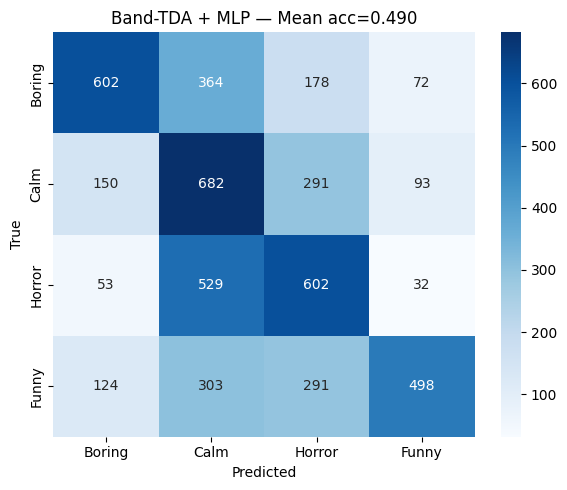

Saved → tda_band_mlp_results.csv


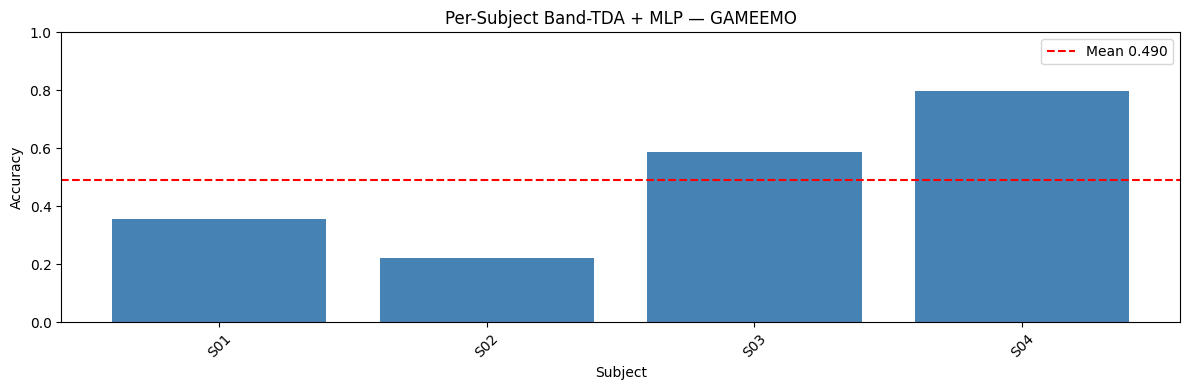

In [41]:
import pandas as pd
# ── CELL 15: Summary ──────────────────────────────────────────────
df_res   = pd.DataFrame(subject_results)
mean_acc = df_res["accuracy"].mean()
std_acc  = df_res["accuracy"].std()

print(f"\n{'='*55}")
print(f"Mean per-subject accuracy : {mean_acc:.4f} +/- {std_acc:.4f}")
print(f"{'='*55}")
print(df_res.to_string(index=False))

print(f"\nOverall classification report:")
print(classification_report(all_y_te_ps, all_y_pred_ps,
                             target_names=EMOTION_LABELS))

plot_cm(all_y_te_ps, all_y_pred_ps,
        f"Band-TDA + MLP — Mean acc={mean_acc:.3f}")

df_res.to_csv("tda_band_mlp_results.csv", index=False)
print("Saved → tda_band_mlp_results.csv")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_res["subject"], df_res["accuracy"], color="steelblue")
ax.axhline(mean_acc, color="red", linestyle="--", label=f"Mean {mean_acc:.3f}")
ax.set_ylim(0, 1)
ax.set_xlabel("Subject"); ax.set_ylabel("Accuracy")
ax.set_title("Per-Subject Band-TDA + MLP — GAMEEMO")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
